In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.fft as fft

import PyOMA as oma
from scipy.interpolate import interp2d

import matplotlib
import scienceplots

In [8]:
#Definições para os gráficos
plt.style.use(['science', 'grid'])


LATEX_WIDTH = 6.29707

aspect_ratio = 6/8
scale = 1.0
FIG_WIDTH = LATEX_WIDTH * scale
FIG_HEIGHT = FIG_WIDTH * aspect_ratio
plt.rcParams['figure.figsize'] = [FIG_WIDTH, FIG_HEIGHT]
plt.rcParams["font.family"] = "serif"

metadata={
            'Creator' : 'Guilherme Zerwes',
            'Producer': 'Guilherme Zerwes',
            'CreationDate': None
        }

plt.rcParams['text.usetex'] = False

# matplotlib.use("pdf")
%matplotlib inline


In [3]:
# Definimos os parâmetros amostrais
fs = 1024 # taxa de amostragem
tf = 256 # tempo total 
Np = fs*tf # número de pontos
t = np.linspace(0,tf,Np,endpoint=False)

#Import dos dados
df = np.asarray(pd.read_table('..\..\Dataset\Treino dataset\zzzAA0.TXT', sep='\t', skiprows=10))
t = df[:,0:]
df = df[:,1:]

In [4]:
print('Decimating...')
q = 5 # Decimation factor
df = signal.decimate(df,  q, ftype='fir', axis=0) # Decimation
fs = fs/q # [Hz] Decimated sampling frequency
print('Decimated')

print('Filtering...')
b, a = signal.butter(2, 100, 'low', fs=1024)
for i in range(df.shape[1]):
        df[:,i] = signal.filtfilt(b, a, df[:,i], padlen=150)
print('Filtered')

Decimating...
Decimated
Filtering...
Filtered


In [5]:
def FDDsvp(data, fs, df=0.01, pov=0.5, window='hann'):
    '''
    This function perform the Frequency Domain Decomposition algorithm.
    
    The function return the plot of the singular values of the power spectral
    density. The cross power spectral density is estimated using 
    scipy.signal.csd() function, which in turn is based on Welch's method.
    Furthermore it returns a dictionary that contains the results needed
    by the function FDDmodEX().
    ----------
    Parameters
    ----------
    data : array
        The time history records (Ndata x Nchannels).
    fs : float
        The sampling frequency.
    df : float
        Desired frequency resolution. Default to 0.01 (Hz).
    pov : float
        Percentage of overlap between segments. Default to 50%.
    window : str or tuple or array_like
        Desired window to use. Window is passed to scipy.signal's get_window
        function (see SciPy.org for more info). Default to "hann" which stands
        for a “Hanning” window.

    -------
    Returns
    -------
    fig1 : matplotlib figure
        Plot of the singular values of the power spectral matrix.
    Results : dictionary
        Dictionary of results to be passed to FDDmodEX()
    '''  
    
    # ndat=data.shape[0] # Number of data points
    nch=data.shape[1] # Number of channels
    freq_max = fs/2 # Nyquist frequency
    nxseg =  fs//0.01 # fs/df number of point per segments
#    nseg = ndat // nxseg # number of segments
    noverlap = nxseg // (1/pov) # Number of overlapping points
    
    # Initialization
    PSD_matr = np.zeros((nch, nch, int((nxseg)/2+1)), dtype=complex) 
    S_val = np.zeros((nch, nch, int((nxseg)/2+1))) 
    S_vec = np.zeros((nch, nch, int((nxseg)/2+1)), dtype=complex) 
    
    # Calculating Auto e Cross-Spectral Density
    for _i in range(0, nch):
        for _j in range(0, nch):
            _f, _Pxy = signal.csd(data[:, _i],data[:, _j], fs=fs, nperseg=nxseg, noverlap=noverlap, window=window)
            PSD_matr[_i, _j, :] = _Pxy
            
    # Singular value decomposition     
    for _i in range(np.shape(PSD_matr)[2]):
        U1, S1, _V1_t = np.linalg.svd(PSD_matr[:,:,_i])
        U1_1=np.transpose(U1) 
        S1 = np.diag(S1)
        S_val[:,:,_i] = S1
        S_vec[:,:,_i] = U1_1
    
    # Plot of the singular values in log scale
    # fig, ax = plt.subplots()
    # for _i in range(nch):
    # #    ax.semilogy(_f, S_val[_i, _i]) # scala log
    #     ax.plot(_f[:], 10*np.log10(S_val[_i, _i])) # decibel
    
    Results={}
    Results['Data'] = {'Data': data}
    Results['Data']['Samp. Freq.'] = fs
    Results['Data']['Freq. Resol.'] = df
    Results['Data']['frequencies'] = _f
    Results['Singular Values'] = S_val
    Results['Singular Vectors'] = S_vec
    Results['PSD Matrix'] = PSD_matr
    
    return _i, Results

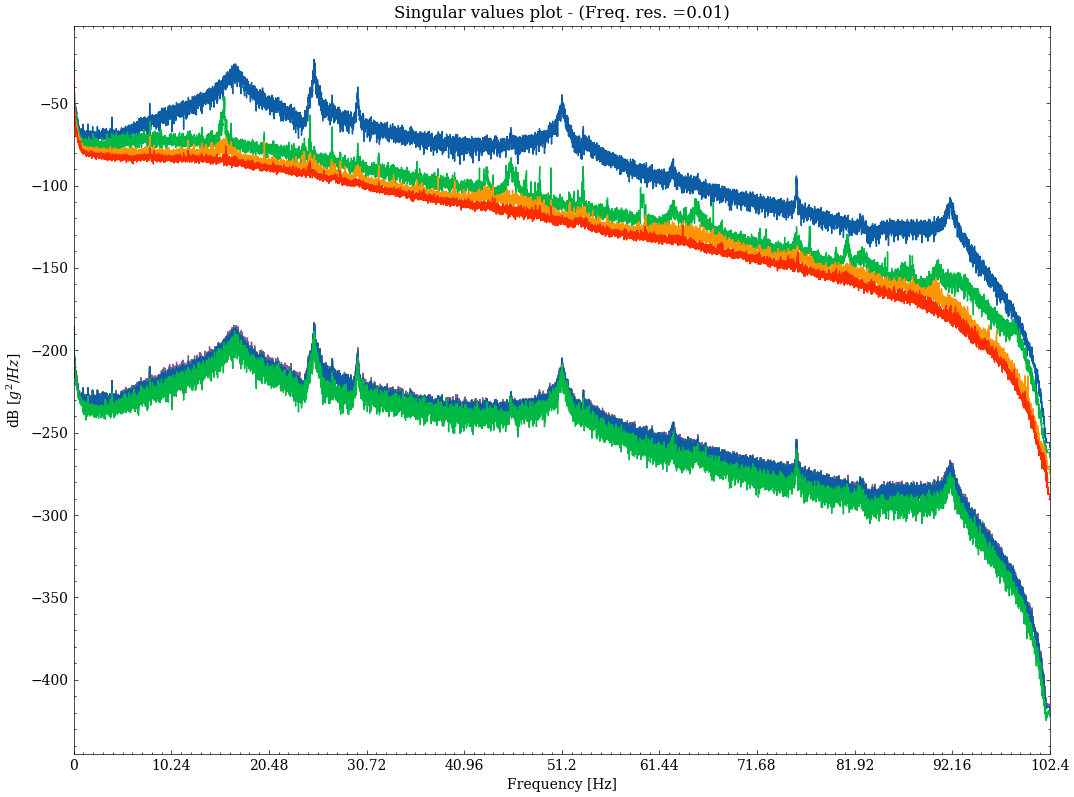

In [7]:
FDD = oma.FDDsvp(df,  fs)

2048 20480.0 10241


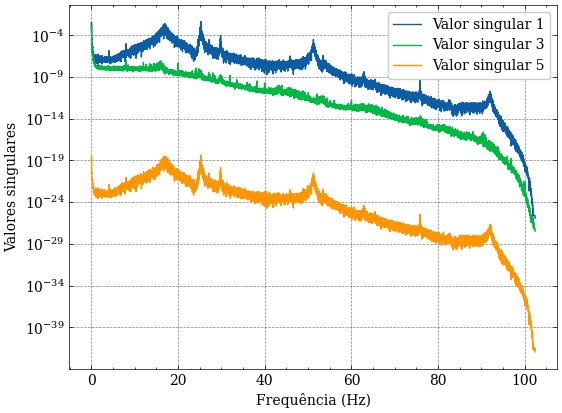

In [10]:
singVals = FDD[1]['Singular Values']
freqs = FDD[1]['Data']['frequencies']

print(len(t)//128, fs/0.01, len(freqs))

fig, ax = plt.subplots(1)
ax.set_yscale("log")
juntas = [0,2,4]

for i in juntas:
    ax.semilogy(freqs[:], singVals[int(i), int(i)], label=f'Valor singular {i+1}')

ax.set_xlabel('Frequência (Hz)')
ax.set_ylabel('Valores singulares')
plt.legend(loc='best')
plt.show()

fig.savefig('./OMA valores singulares.pdf', bbox_inches='tight')

In [9]:
FreQ = [17.4, 24.57, 29.67, 51.2, 75.77, 92.16]
Res_FDD = oma.FDDmodEX(FreQ, FDD[1]) # extracting modal properties using standard FDD

print(f"Frequências: {Res_FDD['Frequencies']}")
Res_FDD['Mode Shapes']

Frequências: [17.38183594 24.58359375 29.67363281 51.20917969 75.75292969 92.16855469]


array([[ 5.78417920e-01+1.13344306e-02j,  4.24769058e-01-5.00894182e-03j,
         1.00000000e+00-0.00000000e+00j, -6.57063462e-01+3.48428560e-03j,
         1.58408245e-01-3.69809683e-02j, -2.54971614e-01-2.06071040e-04j],
       [ 8.85384160e-01+1.11933640e-02j,  6.62206344e-01-9.44991686e-03j,
         6.41468068e-01+3.03848109e-02j, -6.70520783e-01+3.38256065e-03j,
         1.79164257e-01-5.35573545e-03j, -4.91269161e-01-4.83373706e-02j],
       [ 1.00000000e+00-0.00000000e+00j,  7.93925846e-01-2.34262673e-02j,
         1.40626677e-01+5.16220823e-02j, -6.11291790e-01+2.43344916e-02j,
         2.00594555e-01+2.34709985e-02j, -5.88063447e-01+3.16537337e-02j],
       [ 9.18358422e-01+8.95900802e-03j,  8.02740044e-01-1.12630614e-02j,
        -4.25080305e-01+6.82610558e-02j, -5.37176645e-01+2.04037936e-04j,
         1.33948791e-01+3.81496260e-02j, -5.19023354e-01+3.50135670e-02j],
       [ 6.60900953e-01+8.20741858e-03j,  6.94880910e-01-4.77389188e-03j,
        -9.65964246e-01+7.04013104

In [10]:
def plot_colormap(predictions:np.ndarray, axes:plt.Axes, titulo:str=None, colorbar:bool=None):
    '''Função auxiliar para gerar mapas de calor customizados
    
    inputs:
        predictions: ndarray da forma (30,)

        axes: matplotlib axes para uma figura

        titulo: string com o nome a ser adicionado

        colorbar: boleano indicando se o plot deve ou não conter a colorbar
    outputs:
        mapa de calor customizado
    '''

    #Organiza as predições para o formato desejado
    heat = np.reshape(predictions, (5,6), order='F')
    heatmap = axes.imshow(heat, interpolation='bilinear', cmap='jet', vmin=0, vmax=1)

    #monta os ticks nas juntas
    r = 5
    c = 6

    sensx = [int(i) for i in range(c)]*r
    sensy = [i for i in range(r) for j in range(c)]
    axes.scatter(sensx, sensy, color='black', marker='+')

    #Põe título quando fornecido
    axes.set_title(titulo) if titulo else 'nothing'

    # Ajustando os ticks e limites para centralizar as células e iniciar em 1
    axes.set_xticks(np.arange(c))
    axes.set_yticks(np.arange(r))
    axes.set_xticklabels(range(1, c + 1))
    axes.set_yticklabels(range(1, r + 1))
    axes.set_xlim(-0.5, c - 0.5)  # Limites ajustados para centralizar
    axes.set_ylim(r - 0.5, -0.5)  # Inverter Y para alinhar visualmente
    axes.set_aspect('auto')

    #Anota as probabilidades em cada junta
    for x in range(c):
        for y in range(r):
            axes.text(x, y-0.1, f'{heat[y, x]:.2f}', color='white', ha='center', va='center', fontsize=8)

    #Adiciona a colorbar se desejado
    if colorbar:
        cbar_ax = fig.add_axes([1.01, 0.15, 0.05, 0.7])  # Posição da colorbar
        cbar = fig.colorbar(heatmap, cax=cbar_ax)
        cbar.set_label('Probabilidade de dano')  # Rótulo da colorbar
        # cbar.ax.tick_params(labelsize=10)  # Tamanho dos ticks
        cbar.ax.yaxis.set_tick_params(pad=5)  # Espaçamento dos números na colorbar
        cbar.outline.set_linewidth(0.5)  # Fino contorno da colorbar

    

In [57]:
plt.rcParams['grid.color'] = (0.5, 0.5, 0.5, 0.3)

0 0
1 2


C:\Users\Guilherme Zerwes\AppData\Local\Temp\ipykernel_4256\121227355.py:70: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


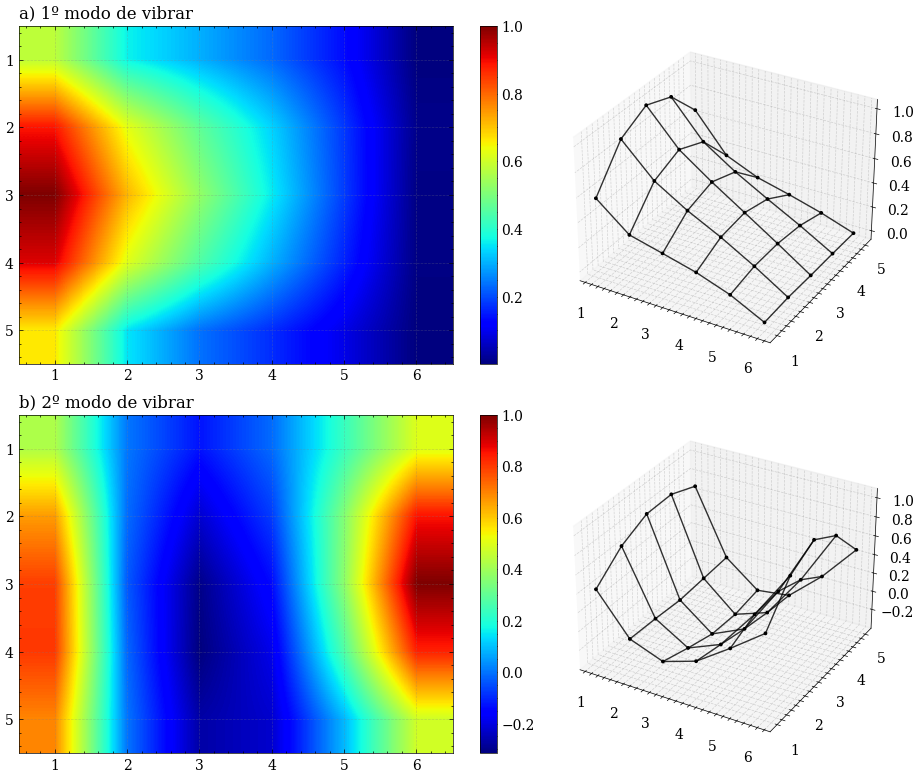

In [64]:
fig = plt.figure(figsize=(FIG_WIDTH,FIG_HEIGHT))
nrows = Res_FDD['Mode Shapes'].shape[1]-4
titulos = [letra + ')' for letra in 'abcdefg']

for i in range(nrows):
    j=2*i
    print(i,j)

    #Heat map
    ax = fig.add_subplot(nrows, 2, j+1)
    heat = np.real(Res_FDD['Mode Shapes'][:,i]).reshape(5,6, order='F')
    heatmap = ax.imshow(heat, interpolation='bilinear', cmap='jet')

    r = 5
    c = 6

    # Ajustando os ticks e limites para centralizar as células e iniciar em 1
    ax.set_xticks(np.arange(c))
    ax.set_yticks(np.arange(r))
    ax.set_xticklabels(range(1, c + 1))
    ax.set_yticklabels(range(1, r + 1))
    # ax.set_xlim(-0.5, c - 0.5)  # Limites ajustados para centralizar
    # ax.set_ylim(r - 0.5, -0.5)  # Inverter Y para alinhar visualmente
    ax.set_aspect('auto')

    #Adiciona a colorbar se desejado
    cbar = ax.figure.colorbar(heatmap, ax=ax)
    # cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")

    # aux = range(nrows)[-i-1]
    # h_cbar = 0.43*aux + 0.1
    # cbar_ax = fig.add_axes([0.9, h_cbar, 0.04, 0.33])  # Posição da colorbar
    # cbar = fig.colorbar(heatmap, cax=cbar_ax)
    # cbar.set_label('Amplitude')  # Rótulo da colorbar
    # cbar.ax.yaxis.set_tick_params(pad=5)  # Espaçamento dos números na colorbar
    # cbar.outline.set_linewidth(0.5)  # Fino contorno da colorbar

    # fig.colorbar(heatmap, shrink=0.5, aspect=5)
    title = f'{titulos[i]} {i+1}º modo de vibrar'
    ax.set_title(title, loc='left')


    #3d Surface
    X = np.arange(0, 6, 1)
    Y = np.arange(0, 5, 1)
    X, Y = np.meshgrid(X, Y)
    Z = np.real(Res_FDD['Mode Shapes'][:,i]).reshape(5,6, order='F')

    #Nice 3d surface
    x2 = np.linspace(0, 6, 120)
    y2 = np.linspace(0, 5, 100)
    f = interp2d(X, Y, Z, kind='cubic')
    Z2 = f(x2, y2)

    X2, Y2 = np.meshgrid(x2, y2)

    ax = fig.add_subplot(nrows, 2, j+2, projection='3d')
    # surf = ax.plot_surface(X2, Y2, Z2, cmap='jet', linewidth=0, antialiased=False, rcount=200, ccount=200)
    ax.plot_wireframe(X,Y,heat, alpha=0.8, edgecolors='k')
    ax.scatter(X,Y,heat, alpha=1, s=3, color='k')
    # ax.grid(False)

    ax.set_xticks(np.arange(c))
    ax.set_yticks(np.arange(r))
    ax.set_xticklabels(range(1, c + 1))
    ax.set_yticklabels(range(1, r + 1))
    ax.set_aspect('auto')

fig.subplots_adjust(wspace=-0.2, hspace=0.15)
plt.tight_layout()
plt.show()
fig.savefig(f'./Modos de vibrar {i} e {i+1}.pdf', bbox_inches='tight')


In [121]:
for i in range(5):
    fig = plt.figure(figsize=(FIG_WIDTH,FIG_HEIGHT))
    print(i)

    #Heat map
    ax = fig.add_subplot(1, 2, 1)
    heat = np.real(Res_FDD['Mode Shapes'][:,i]).reshape(6,5)
    heatmap = ax.imshow(heat, interpolation='bilinear', cmap='jet')

    r = 6
    c = 5

    sensx = [int(i) for i in range(c)]*r
    sensy = [i for i in range(r) for j in range(c)]
    ax.scatter(sensx, sensy, color='black', marker='+')
    
    # fig.colorbar(heatmap, shrink=0.5, aspect=5)
    title = 'a) Mapa de calor'
    ax.set_title(title)

    #3d Surface
    X = np.arange(0, 6, 1)
    Y = np.arange(0, 5, 1)
    X, Y = np.meshgrid(X, Y)
    Z = np.real(Res_FDD['Mode Shapes'][:,i]).reshape(5,6)

    #Nice 3d surface
    x2 = np.linspace(0, 6, 60)
    y2 = np.linspace(0, 5, 50)
    f = interp2d(X, Y, Z, kind='cubic')
    Z2 = f(x2, y2)

    X2, Y2 = np.meshgrid(x2, y2)
    # fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
    ax = fig.add_subplot(1, 2, 2, projection='3d')
    surf = ax.plot_surface(X2, Y2, Z2, cmap='jet', linewidth=0, antialiased=False, rcount=200, ccount=200)
    # fig.colorbar(surf, shrink=0.5, aspect=5)

    title = 'b) Superfície 3D'
    ax.set_title(title)


    fig.subplots_adjust(left=1, right=1.1)

    plt.tight_layout(pad=0)

    cbar_ax = fig.add_axes([1.05, 0.15, 0.05, 0.7])
    fig.colorbar(heatmap, cax=cbar_ax)

    plt.show()
    fig.savefig(f'./{i} Modos de vibrar', bbox_inches='tight')

0


C:\Users\Guilherme Zerwes\AppData\Local\Temp\ipykernel_15972\3640796891.py:50: UserWarning: Matplotlib is currently using pdf, which is a non-GUI backend, so cannot show the figure.
  plt.show()


1


c:\Users\Guilherme Zerwes\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\interpolate\_fitpack_impl.py:977: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients already exceeds the number of data points m.
Probable causes: either s or m too small. (fp>s)
	kx,ky=3,3 nx,ny=9,11 m=30 fp=0.017726 s=0.000000
  warnings.warn(RuntimeWarning(_iermess2[ierm][0] + _mess))
C:\Users\Guilherme Zerwes\AppData\Local\Temp\ipykernel_15972\3640796891.py:50: UserWarning: Matplotlib is currently using pdf, which is a non-GUI backend, so cannot show the figure.
  plt.show()


2


c:\Users\Guilherme Zerwes\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\interpolate\_fitpack_impl.py:977: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients already exceeds the number of data points m.
Probable causes: either s or m too small. (fp>s)
	kx,ky=3,3 nx,ny=9,11 m=30 fp=0.495171 s=0.000000
  warnings.warn(RuntimeWarning(_iermess2[ierm][0] + _mess))
C:\Users\Guilherme Zerwes\AppData\Local\Temp\ipykernel_15972\3640796891.py:50: UserWarning: Matplotlib is currently using pdf, which is a non-GUI backend, so cannot show the figure.
  plt.show()


3


C:\Users\Guilherme Zerwes\AppData\Local\Temp\ipykernel_15972\3640796891.py:50: UserWarning: Matplotlib is currently using pdf, which is a non-GUI backend, so cannot show the figure.
  plt.show()


4


C:\Users\Guilherme Zerwes\AppData\Local\Temp\ipykernel_15972\3640796891.py:50: UserWarning: Matplotlib is currently using pdf, which is a non-GUI backend, so cannot show the figure.
  plt.show()
